In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.activations import selu
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.metrics import RootMeanSquaredError,MeanAbsolutePercentageError
from sklearn.model_selection import train_test_split
from tensorflow.keras.losses import LogCosh,MeanSquaredError,MeanAbsoluteError,MeanSquaredLogarithmicError
import os
from tensorflow.keras.models import load_model
import matplotlib.dates as mdates
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [2]:
import json
class MetricsCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, filepath, monitor='val_root_mean_squared_error', mode='min'):
        super().__init__()
        self.filepath = filepath
        self.monitor = monitor
        self.best = None
        self.mode = mode
        if self.mode == 'min':
            self.compare = lambda a, b: a < b
            self.best = float('inf')
        else:
            self.compare = lambda a, b: a > b
            self.best = -float('inf')

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is None:
            return
        if self.compare(current, self.best):
            self.best = current
            # Сохраняем все текущие метрики эпохи в JSON
            with open(self.filepath, 'w', encoding='utf-8') as f:
                json.dump({key: float(value) for key, value in logs.items()}, f, ensure_ascii=False, indent=4)
            print(f"\nМетрики для лучшей модели сохранены в {self.filepath} на эпохе {epoch+1}")


In [3]:
def plot_history_errors(history, train_key=None, val_key=None, title='Training / validation error'):
    if history is None:
        raise ValueError("history == None: нет истории обучения, график построить нельзя")

    keys = list(history.history.keys())
    print("history keys:", keys)

    # выбор ключей для train
    if train_key is None:
        if 'root_mean_squared_error' in keys:
            train_key = 'root_mean_squared_error'
        elif 'loss' in keys:
            train_key = 'loss'
        else:
            raise ValueError("Не найден ключ для train ошибки в history.history")

    # выбор ключей для val
    if val_key is None:
        if 'val_root_mean_squared_error' in keys:
            val_key = 'val_root_mean_squared_error'
        elif 'val_loss' in keys:
            val_key = 'val_loss'
        else:
            raise ValueError("Не найден ключ для val ошибки в history.history")

    train_err = history.history[train_key]
    val_err   = history.history[val_key]

    # --- отдельный график train ---
    plt.figure(figsize=(8, 4))
    plt.plot(train_err, color='black')
    plt.xlabel('epoch')
    plt.ylabel('error')
    plt.title(f'{title} - train')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- отдельный график test/val ---
    plt.figure(figsize=(8, 4))
    plt.plot(val_err, color='gray')
    plt.xlabel('epoch')
    plt.ylabel('error')
    plt.title(f'{title} - test')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [4]:
# загружаем те же данные, что используются в LSTM модели
print("загрузка данных...")
data = pd.read_csv('bitcoin_2017_to_2023.csv')

print(f"Колонки в данных: {list(data.columns)}")  # Проверим колонки

# преобразуем timestamp в datetime, но НЕ устанавливаем как индекс
data['timestamp'] = pd.to_datetime(data['timestamp'])

# Сортируем по дате по возрастанию (2017 -> 2023)
data = data.sort_values('timestamp').reset_index(drop=True)

print(f"период данных: {data['timestamp'].min()} до {data['timestamp'].max()}")
print(f"частота данных: {pd.infer_freq(data['timestamp'][:10])}")


загрузка данных...
Колонки в данных: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']
период данных: 2017-08-17 04:00:00 до 2023-08-01 13:19:00
частота данных: min


In [5]:
from sklearn.preprocessing import StandardScaler

features = ['timestamp', 'open', 'high', 'close', 'volume',
            'quote_asset_volume', 'number_of_trades',
            'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

data['timestamp'] = pd.to_datetime(data['timestamp'])
data['timestamp'] = data['timestamp'].astype('int64')  # числовое представление даты

X = data[features]
y = data['low']

train_size = 40000
X_train = X.iloc[:train_size].copy()
X_test  = X.iloc[train_size:train_size + 10000].copy()
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:train_size + 10000]

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

X_train_num = X_train[features_num].values
X_test_num  = X_test[features_num].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled  = scaler.transform(X_test_num)

X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0],
                                      X_train_scaled.shape[1],
                                      1).astype('float32')
X_test_lstm  = X_test_scaled.reshape(X_test_scaled.shape[0],
                                     X_test_scaled.shape[1],
                                     1).astype('float32')

print("X_train_lstm shape:", X_train_lstm.shape)  # (160000, 9, 1)
print("X_test_lstm shape:", X_test_lstm.shape)   # (40000, 9, 1)


X_train_lstm shape: (40000, 9, 1)
X_test_lstm shape: (10000, 9, 1)


In [6]:
model_path = 'best_model_50.keras'
metrics_path = 'best_model_metrics_50.json'

if os.path.exists(model_path):
    print("Загружаем существующую обученную модель...")
    model = load_model(model_path)
    print(model.summary())
    print("Оценка на тесте:")
else:
    print("Обучаем новую модель с LSTM...")

    model = Sequential([
        LSTM(16, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
        Dropout(0.17),
        LSTM(16, return_sequences=False, activation='relu'),
        Dropout(0.17),
        Dense(1)
    ])

    model.compile(
        optimizer=Nadam(learning_rate=0.001),
        loss=LogCosh(),
        metrics=[
            RootMeanSquaredError(),
            MeanAbsoluteError(name='mae'),
            MeanAbsolutePercentageError(name='mape'),
            tf.keras.metrics.R2Score(name='r2')
        ]
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor='val_root_mean_squared_error',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor='val_root_mean_squared_error',
        patience=25,
        mode='min',
        restore_best_weights=True,
        verbose=1
    )

    metrics_checkpoint = MetricsCheckpoint(metrics_path, monitor='val_root_mean_squared_error', mode='min')

    history = model.fit(
        X_train_lstm, y_train,
        epochs=488,
        batch_size=216,
        validation_data=(X_test_lstm, y_test),
        callbacks=[checkpoint, early_stopping, metrics_checkpoint]
    )

    print("Обучение завершено. Лучшая модель и метрики сохранены.")

Обучаем новую модель с LSTM...


c:\Users\Егор\Desktop\Network\Network\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/488
185/186 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3733.8589 - mae: 3734.5529 - mape: 87.0202 - r2: -274.2408 - root_mean_squared_error: 3908.8677
Epoch 1: val_root_mean_squared_error improved from None to 394.07904, saving model to best_model_50.keras

Метрики для лучшей модели сохранены в best_model_metrics_50.json на эпохе 1
186/186 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 2505.8035 - mae: 2497.8975 - mape: 58.4939 - r2: -164.7253 - root_mean_squared_error: 3054.5247 - val_loss: 294.7803 - val_mae: 299.9485 - val_mape: 7.6122 - val_r2: -1.5734 - val_root_mean_squared_error: 394.0790
Epoch 2/488
181/186 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 588.3785 - mae: 589.0713 - mape: 13.7293 - r2: -8.9480 - root_mean_squared_error: 748.5091
Epoch 2: val_root_mean_squared_error improved from 394.07904 to 217.35799, saving model to best_model_50.keras

Метрики для лучшей модели сохранены в best_model_metrics_50.json на эпохе 2
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 574.09

slice_df shape: (10000, 10)
Model input shape: (None, 9, 1)
slice_X_lstm shape: (10000, 9, 1)


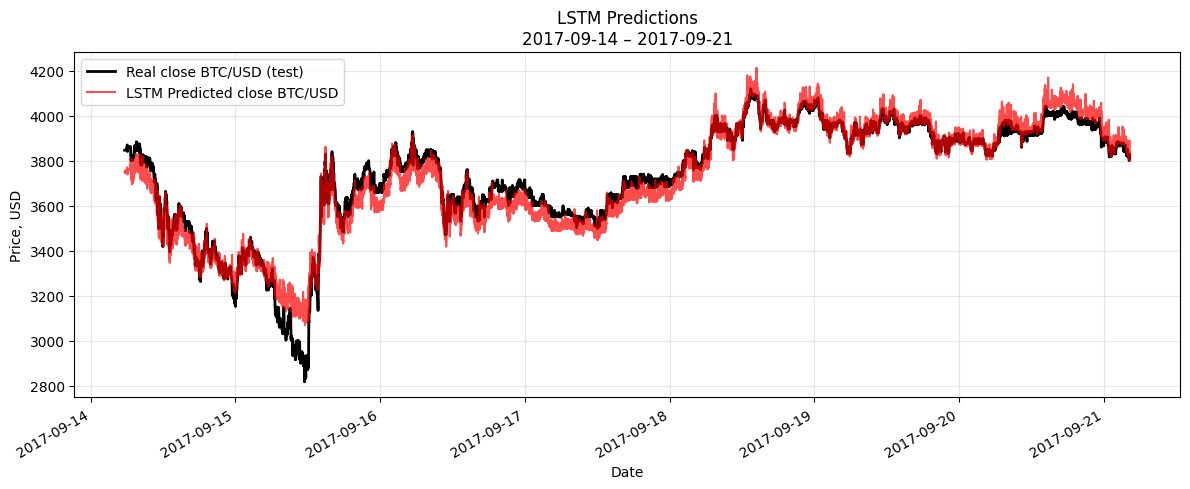

Тестовая выборка: 2017-09-14 05:39:00 – 2017-09-21 04:18:00
y_pred range: 3069.09 - 4212.87
y_real range: 2817.00 - 4119.50


In [ ]:
slice_df = data.iloc[train_size:train_size + 10000].copy()
print("slice_df shape:", slice_df.shape)

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

slice_X_num = slice_df[features_num].astype('float32').values

slice_X_scaled = scaler.transform(slice_X_num)

slice_X_lstm = slice_X_scaled.reshape((slice_X_scaled.shape[0],
                                       slice_X_scaled.shape[1],
                                       1)).astype('float32')

print(f"Model input shape: {model.input_shape}") 
print(f"slice_X_lstm shape: {slice_X_lstm.shape}")

y_pred = model.predict(slice_X_lstm, batch_size=256, verbose=0).flatten()

dates = pd.to_datetime(slice_df['timestamp'])
y_real = y_test.values

start_date = dates.min()
end_date = dates.max()

plt.figure(figsize=(12, 5))
plt.plot(dates, y_real, label='Real close BTC/USD (test)', color='black', linewidth=2)
plt.plot(dates, y_pred, label='LSTM Predicted close BTC/USD', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price, USD')
plt.title(f'LSTM Predictions\n{start_date.date()} – {end_date.date()}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Тестовая выборка: {start_date} – {end_date}")
print(f"y_pred range: {y_pred.min():.2f} - {y_pred.max():.2f}")
print(f"y_real range: {y_real.min():.2f} - {y_real.max():.2f}")


Обучаем новую модель...
Epoch 1/310


c:\Users\Егор\Desktop\Network\Network\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2217.1301 - mae: 2217.8223 - mape: 51.4667 - r2: -148.0951 - root_mean_squared_error: 2761.5473
Epoch 1: val_root_mean_squared_error improved from None to 71.53294, saving model to best_model_2_50.keras

Метрики для лучшей модели сохранены в best_model_2_metrics_50.json на эпохе 1
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 1072.1019 - mae: 1072.7942 - mape: 24.8836 - r2: -54.9689 - root_mean_squared_error: 1774.7117 - val_loss: 48.6303 - val_mae: 49.3176 - val_mape: 1.3908 - val_r2: 0.9152 - val_root_mean_squared_error: 71.5329
Epoch 2/310
398/400 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 386.5312 - mae: 387.2237 - mape: 9.0039 - r2: -3.1935 - root_mean_squared_error: 485.5290
Epoch 2: val_root_mean_squared_error did not improve from 71.53294
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 380.6904 - mae: 381.3829 - mape: 8.8689 - r2: -3.0725 - root_mean_squared_error: 478.8622 - val_loss: 94.5406 - val_mae: 95.2326 - val_mape: 2.

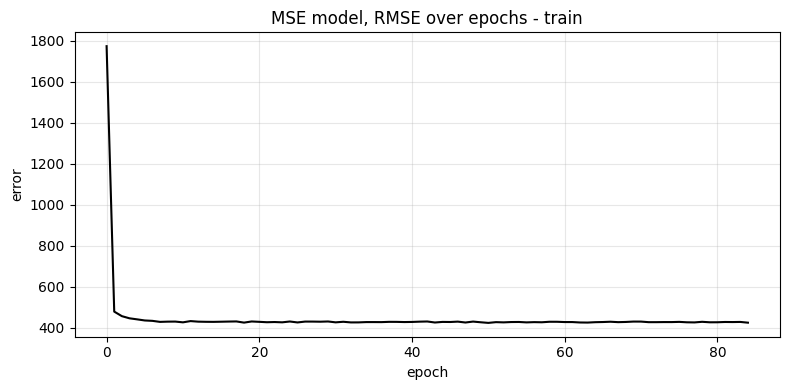

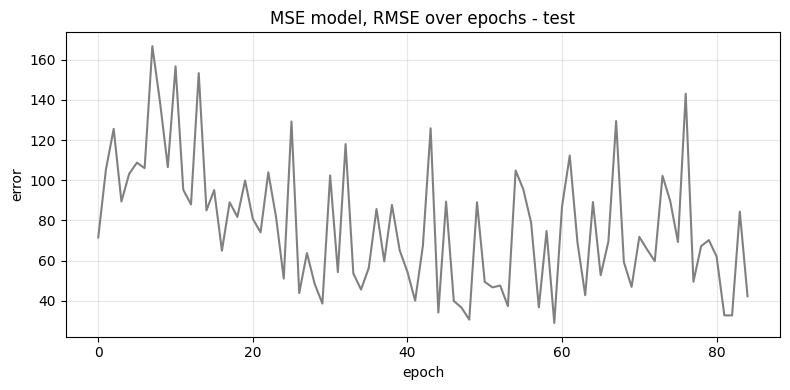

In [8]:
model_path = 'best_model_2_50.keras'
metrics_path = 'best_model_2_metrics_50.json'
history = None
if os.path.exists(model_path):
    print("Загружаем существующую обученную модель...")
    model = load_model(model_path)
    print(model.summary())         
    print("Оценка на тесте:")
else:
    print("Обучаем новую модель...")
    model = Sequential([
        LSTM(26, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
        Dropout(0.19),
        LSTM(26, return_sequences=False, activation='linear'),
        Dropout(0.19),
        Dense(1)
    ])

    model.compile(
        optimizer=Nadam(),
        loss=LogCosh(),
        metrics=[
            RootMeanSquaredError(),
            MeanAbsoluteError(name='mae'),
            MeanAbsolutePercentageError(name='mape'),
            tf.keras.metrics.R2Score(name='r2')
        ]
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor='val_root_mean_squared_error',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor='val_root_mean_squared_error',
        patience=25,
        mode='min',
        restore_best_weights=True,
        verbose=1
    )

    metrics_checkpoint = MetricsCheckpoint(
        metrics_path,
        monitor='val_root_mean_squared_error',
        mode='min'
    )

    history = model.fit(
        X_train_lstm, y_train,
        epochs=310,
        batch_size=100,
        validation_data=(X_test_lstm, y_test),
        callbacks=[checkpoint, early_stopping, metrics_checkpoint]
    )

    print("Обучение завершено. Лучшая модель и метрики сохранены.")

if history is not None:
    plot_history_errors(history, title='MSE model, RMSE over epochs')
else:
    print("Модель загружена из файла: history нет, график по эпохам построить нельзя.")

slice_df shape: (10000, 10)
Model input shape: (None, 9, 1)
slice_X_lstm shape: (10000, 9, 1)


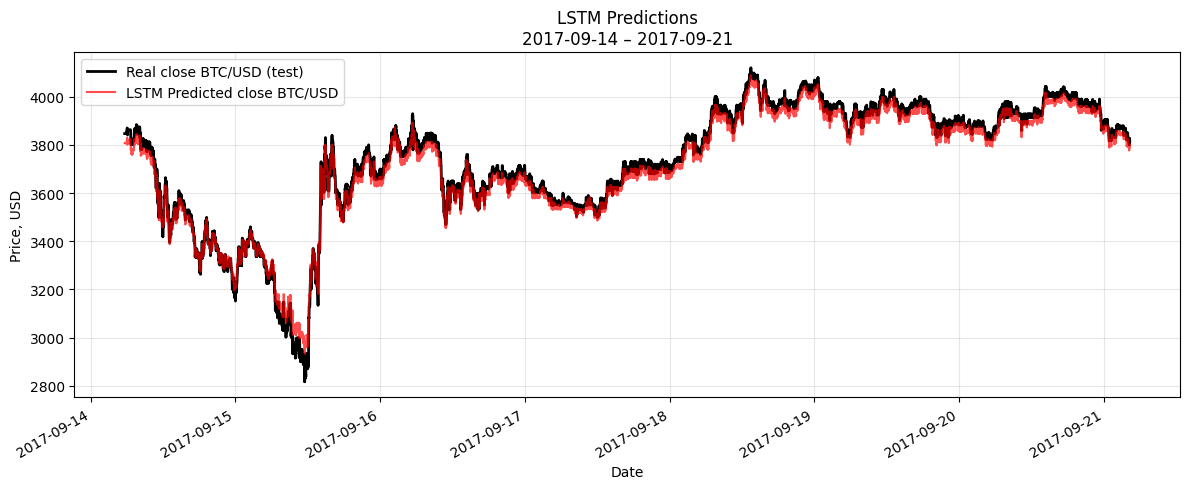

Тестовая выборка: 2017-09-14 05:39:00 – 2017-09-21 04:18:00
y_pred range: 2932.24 - 4088.94
y_real range: 2817.00 - 4119.50


In [ ]:
slice_df = data.iloc[train_size:train_size + 10000].copy()
print("slice_df shape:", slice_df.shape)

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

slice_X_num = slice_df[features_num].astype('float32').values

slice_X_scaled = scaler.transform(slice_X_num)

slice_X_lstm = slice_X_scaled.reshape((slice_X_scaled.shape[0],
                                       slice_X_scaled.shape[1],
                                       1)).astype('float32')

print(f"Model input shape: {model.input_shape}") 
print(f"slice_X_lstm shape: {slice_X_lstm.shape}")

y_pred = model.predict(slice_X_lstm, batch_size=256, verbose=0).flatten()

dates = pd.to_datetime(slice_df['timestamp'])
y_real = y_test.values

start_date = dates.min()
end_date = dates.max()

plt.figure(figsize=(12, 5))
plt.plot(dates, y_real, label='Real close BTC/USD (test)', color='black', linewidth=2)
plt.plot(dates, y_pred, label='LSTM Predicted close BTC/USD', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price, USD')
plt.title(f'LSTM Predictions\n{start_date.date()} – {end_date.date()}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Тестовая выборка: {start_date} – {end_date}")
print(f"y_pred range: {y_pred.min():.2f} - {y_pred.max():.2f}")
print(f"y_real range: {y_real.min():.2f} - {y_real.max():.2f}")


Обучаем новую модель...
Epoch 1/381


c:\Users\Егор\Desktop\Network\Network\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


492/500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12681074.7002 - mae: 3165.5964 - mape: 73.8127 - r2: -221.5437 - root_mean_squared_error: 3497.6347
Epoch 1: val_root_mean_squared_error improved from None to 488.72009, saving model to best_model_3_50.keras

Метрики для лучшей модели сохранены в best_model_3_metrics_50.json на эпохе 1
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 6048581.0000 - mae: 1738.9041 - mape: 40.6756 - r2: -106.4936 - root_mean_squared_error: 2459.3862 - val_loss: 238847.3281 - val_mae: 482.5315 - val_mape: 13.0853 - val_r2: -2.9573 - val_root_mean_squared_error: 488.7201
Epoch 2/381
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 153646.3273 - mae: 277.6426 - mape: 6.5021 - r2: -1.7523 - root_mean_squared_error: 391.9182
Epoch 2: val_root_mean_squared_error improved from 488.72009 to 175.74290, saving model to best_model_3_50.keras

Метрики для лучшей модели сохранены в best_model_3_metrics_50.json на эпохе 2
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss:

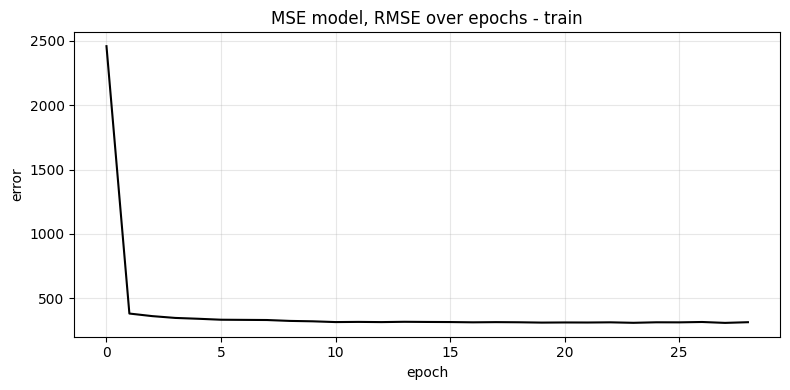

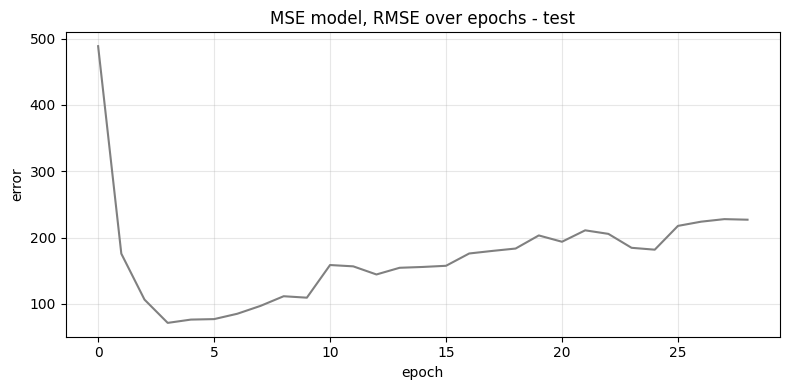

In [10]:
model_path = 'best_model_3_50.keras'
metrics_path = 'best_model_3_metrics_50.json'
history = None
if os.path.exists(model_path):
    print("Загружаем существующую обученную модель...")
    model = load_model(model_path)
    print(model.summary())              # структура модели
    print("Оценка на тесте:")
else:
    print("Обучаем новую модель...")
    model = Sequential([
        LSTM(6, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
        Dropout(0.03),
        LSTM(6, return_sequences=False, activation='linear'),
        Dropout(0.03),
        Dense(1)
    ])

    model.compile(
        optimizer=Nadam(),
        loss=MeanSquaredError(),
        metrics=[
            RootMeanSquaredError(),
            MeanAbsoluteError(name='mae'),
            MeanAbsolutePercentageError(name='mape'),
            tf.keras.metrics.R2Score(name='r2')
        ]
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor='val_root_mean_squared_error',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor='val_root_mean_squared_error',
        patience=25,
        mode='min',
        restore_best_weights=True,
        verbose=1
    )

    metrics_checkpoint = MetricsCheckpoint(
        metrics_path,
        monitor='val_root_mean_squared_error',
        mode='min'
    )

    history = model.fit(
        X_train_lstm, y_train,
        epochs=381,
        batch_size=80,
        validation_data=(X_test_lstm, y_test),
        callbacks=[checkpoint, early_stopping, metrics_checkpoint]
    )

    print("Обучение завершено. Лучшая модель и метрики сохранены.")

if history is not None:
    plot_history_errors(history, title='MSE model, RMSE over epochs')
else:
    print("Модель загружена из файла: history нет, график по эпохам построить нельзя.")


slice_df shape: (10000, 10)
Model input shape: (None, 9, 1)
slice_X_lstm shape: (10000, 9, 1)


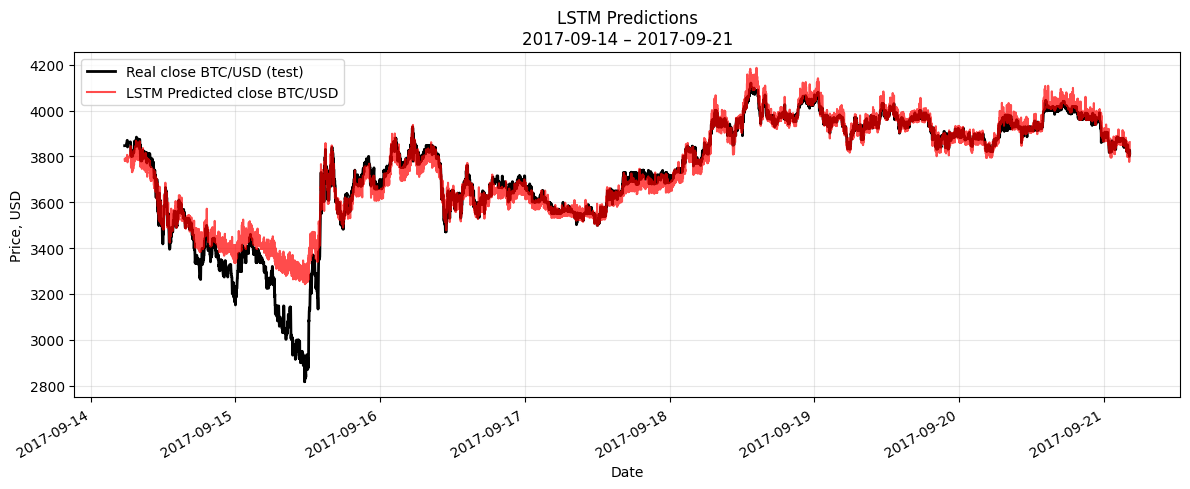

Тестовая выборка: 2017-09-14 05:39:00 – 2017-09-21 04:18:00
y_pred range: 3242.65 - 4186.08
y_real range: 2817.00 - 4119.50


In [ ]:
slice_df = data.iloc[train_size:train_size + 10000].copy()
print("slice_df shape:", slice_df.shape)

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

slice_X_num = slice_df[features_num].astype('float32').values

slice_X_scaled = scaler.transform(slice_X_num)

slice_X_lstm = slice_X_scaled.reshape((slice_X_scaled.shape[0],
                                       slice_X_scaled.shape[1],
                                       1)).astype('float32')

print(f"Model input shape: {model.input_shape}") 
print(f"slice_X_lstm shape: {slice_X_lstm.shape}")

y_pred = model.predict(slice_X_lstm, batch_size=256, verbose=0).flatten()

dates = pd.to_datetime(slice_df['timestamp'])
y_real = y_test.values

start_date = dates.min()
end_date = dates.max()

plt.figure(figsize=(12, 5))
plt.plot(dates, y_real, label='Real close BTC/USD (test)', color='black', linewidth=2)
plt.plot(dates, y_pred, label='LSTM Predicted close BTC/USD', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price, USD')
plt.title(f'LSTM Predictions\n{start_date.date()} – {end_date.date()}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Тестовая выборка: {start_date} – {end_date}")
print(f"y_pred range: {y_pred.min():.2f} - {y_pred.max():.2f}")
print(f"y_real range: {y_real.min():.2f} - {y_real.max():.2f}")


Обучаем новую модель...
Epoch 1/373


c:\Users\Егор\Desktop\Network\Network\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


491/500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8500080.2739 - mae: 2209.1855 - mape: 51.3914 - r2: -151.6383 - root_mean_squared_error: 2781.0071
Epoch 1: val_root_mean_squared_error improved from None to 215.43246, saving model to best_model_4_50.keras

Метрики для лучшей модели сохранены в best_model_4_metrics_50.json на эпохе 1
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 3109736.0000 - mae: 1027.3641 - mape: 23.9053 - r2: -54.2718 - root_mean_squared_error: 1763.4443 - val_loss: 46411.1445 - val_mae: 201.0521 - val_mape: 5.4457 - val_r2: 0.2310 - val_root_mean_squared_error: 215.4325
Epoch 2/373
492/500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 191310.8189 - mae: 346.8388 - mape: 8.0720 - r2: -2.3990 - root_mean_squared_error: 437.3445
Epoch 2: val_root_mean_squared_error improved from 215.43246 to 167.64957, saving model to best_model_4_50.keras

Метрики для лучшей модели сохранены в best_model_4_metrics_50.json на эпохе 2
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1824

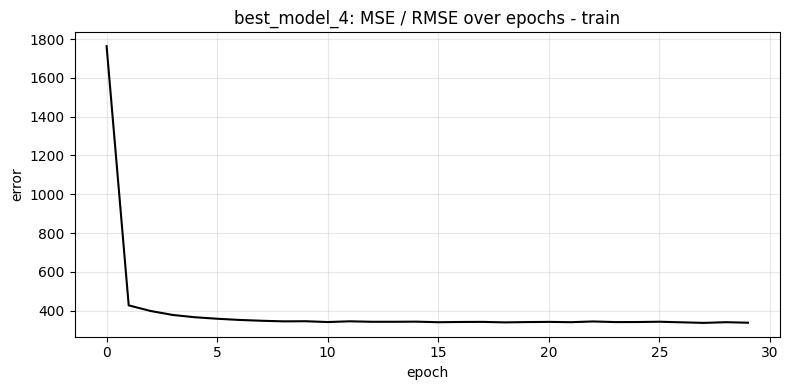

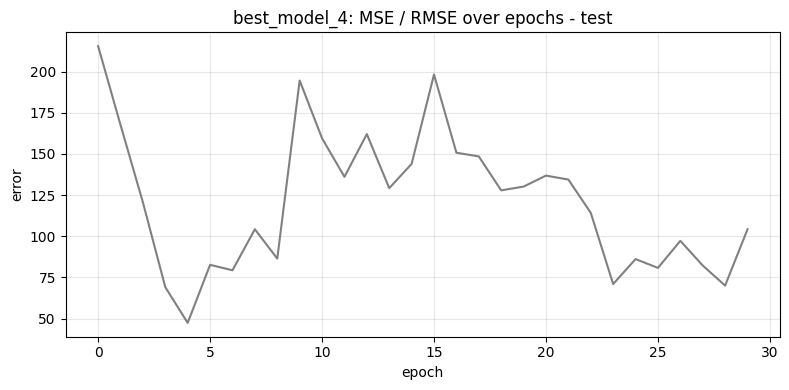

In [12]:
model_path = 'best_model_4_50.keras'
metrics_path = 'best_model_4_metrics_50.json'
history = None
if os.path.exists(model_path):
    print("Загружаем существующую обученную модель...")
    model = load_model(model_path)
    print(model.summary())         
    print("Оценка на тесте:")
    eval_res = model.evaluate(X_test, y_test, verbose=0)
    print("loss =", eval_res[0])
    if len(eval_res) > 1:
        print("RMSE =", eval_res[1])
else:
    print("Обучаем новую модель...")
    model = Sequential([
        LSTM(14, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
        Dropout(0.08),
        LSTM(14, return_sequences=False, activation='linear'),
        Dropout(0.08),
        Dense(1)
    ])

    model.compile(
        optimizer=Nadam(),
        loss=MeanSquaredError(),
        metrics=[
            RootMeanSquaredError(),
            MeanAbsoluteError(name='mae'),
            MeanAbsolutePercentageError(name='mape'),
            tf.keras.metrics.R2Score(name='r2')
        ]
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor='val_root_mean_squared_error',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor='val_root_mean_squared_error',
        patience=25,
        mode='min',
        restore_best_weights=True,
        verbose=1
    )

    metrics_checkpoint = MetricsCheckpoint(
        metrics_path,
        monitor='val_root_mean_squared_error',
        mode='min'
    )

    history = model.fit(
        X_train_lstm, y_train,
        epochs=373,
        batch_size=80,
        validation_data=(X_test_lstm, y_test),
        callbacks=[checkpoint, early_stopping, metrics_checkpoint]
    )

    print("Обучение завершено. Лучшая модель и метрики сохранены.")

if history is not None:
    plot_history_errors(history, title='best_model_4: MSE / RMSE over epochs')
else:
    print("Модель загружена из файла: history отсутствует, "
          "поэтому график обучения по эпохам в этом запуске построить нельзя.")


slice_df shape: (10000, 10)
Model input shape: (None, 9, 1)
slice_X_lstm shape: (10000, 9, 1)


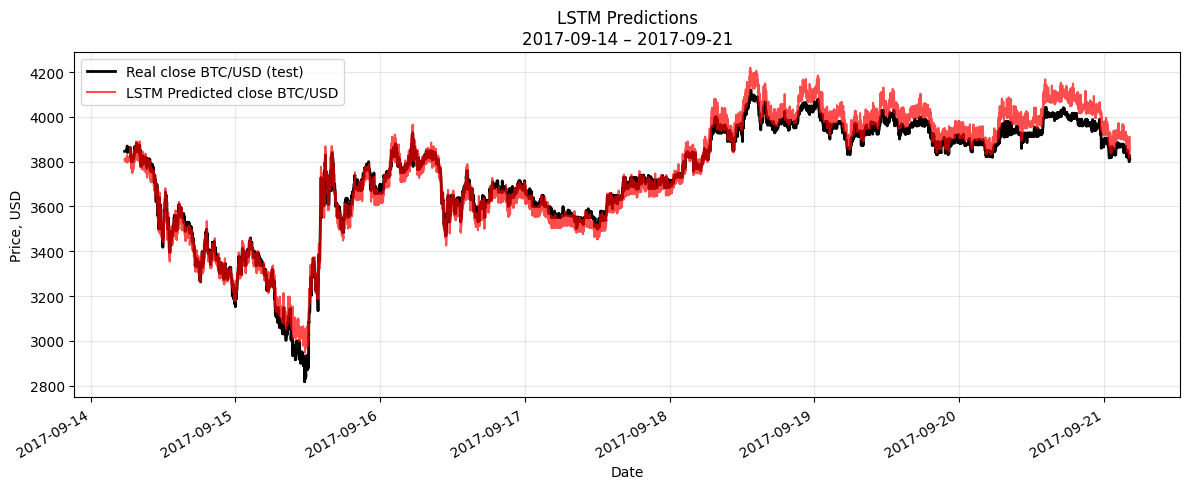

Тестовая выборка: 2017-09-14 05:39:00 – 2017-09-21 04:18:00
y_pred range: 2946.53 - 4219.47
y_real range: 2817.00 - 4119.50


In [ ]:
slice_df = data.iloc[train_size:train_size + 10000].copy()
print("slice_df shape:", slice_df.shape)

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

slice_X_num = slice_df[features_num].astype('float32').values

slice_X_scaled = scaler.transform(slice_X_num)

slice_X_lstm = slice_X_scaled.reshape((slice_X_scaled.shape[0],
                                       slice_X_scaled.shape[1],
                                       1)).astype('float32')

print(f"Model input shape: {model.input_shape}") 
print(f"slice_X_lstm shape: {slice_X_lstm.shape}")

y_pred = model.predict(slice_X_lstm, batch_size=256, verbose=0).flatten()

dates = pd.to_datetime(slice_df['timestamp'])
y_real = y_test.values

start_date = dates.min()
end_date = dates.max()

plt.figure(figsize=(12, 5))
plt.plot(dates, y_real, label='Real close BTC/USD (test)', color='black', linewidth=2)
plt.plot(dates, y_pred, label='LSTM Predicted close BTC/USD', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price, USD')
plt.title(f'LSTM Predictions\n{start_date.date()} – {end_date.date()}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Тестовая выборка: {start_date} – {end_date}")
print(f"y_pred range: {y_pred.min():.2f} - {y_pred.max():.2f}")
print(f"y_real range: {y_real.min():.2f} - {y_real.max():.2f}")


Обучаем новую модель...
Epoch 1/494


c:\Users\Егор\Desktop\Network\Network\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4297.6907 - mae: 4297.6921 - mape: 100.0000 - r2: -325.1684 - root_mean_squared_error: 4304.2912
Epoch 1: val_root_mean_squared_error improved from None to 3741.80762, saving model to best_model_5_50.keras

Метрики для лучшей модели сохранены в best_model_5_metrics_50.json на эпохе 1
364/364 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 4297.2598 - mae: 4297.2192 - mape: 100.0000 - r2: -328.0647 - root_mean_squared_error: 4303.7983 - val_loss: 3733.7336 - val_mae: 3733.8503 - val_mape: 100.0005 - val_r2: -231.0222 - val_root_mean_squared_error: 3741.8076
Epoch 2/494
360/364 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4297.5272 - mae: 4297.5271 - mape: 99.9999 - r2: -328.5232 - root_mean_squared_error: 4304.0589
Epoch 2: val_root_mean_squared_error improved from 3741.80762 to 3741.79834, saving model to best_model_5_50.keras

Метрики для лучшей модели сохранены в best_model_5_metrics_50.json на эпохе 2
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - l

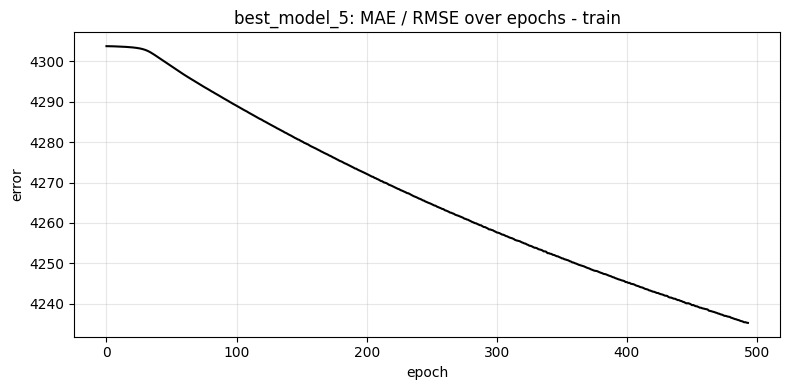

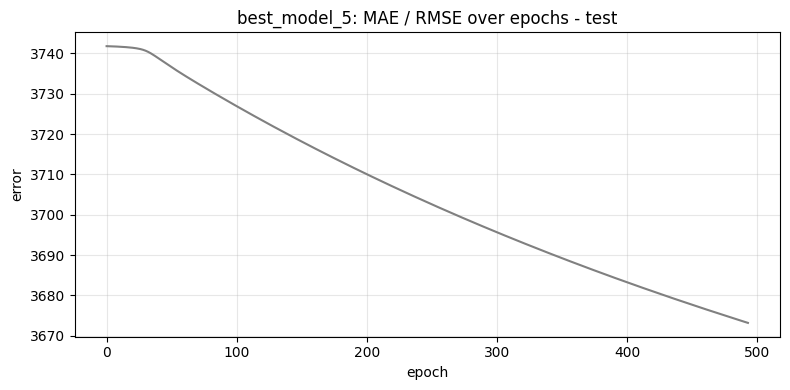

In [14]:
model_path = 'best_model_5_50.keras'
metrics_path = 'best_model_5_metrics_50.json'
history = None

if os.path.exists(model_path):
    print("Загружаем существующую обученную модель...")
    model = load_model(model_path)
else:
    print("Обучаем новую модель...")
    model = Sequential([
        LSTM(5, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
        Dropout(0.11),
        LSTM(5, return_sequences=False, activation='tanh'),
        Dropout(0.11),
        Dense(1)
    ])

    model.compile(
        optimizer='Adadelta',
        loss=MeanAbsoluteError(),
        metrics=[
            RootMeanSquaredError(),
            MeanAbsoluteError(name='mae'),
            MeanAbsolutePercentageError(name='mape'),
            tf.keras.metrics.R2Score(name='r2')
        ]
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor='val_root_mean_squared_error',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor='val_root_mean_squared_error',
        patience=25,
        mode='min',
        restore_best_weights=True,
        verbose=1
    )

    metrics_checkpoint = MetricsCheckpoint(
        metrics_path,
        monitor='val_root_mean_squared_error',
        mode='min'
    )

    history = model.fit(
        X_train_lstm, y_train,
        epochs=494,
        batch_size=110,
        validation_data=(X_test_lstm, y_test),
        callbacks=[checkpoint, early_stopping, metrics_checkpoint]
    )

    print("Обучение завершено. Лучшая модель и метрики сохранены.")

if history is not None:
    plot_history_errors(history, title='best_model_5: MAE / RMSE over epochs')
else:
    print("Модель загружена из файла: history отсутствует, "
          "поэтому график обучения по эпохам в этом запуске построить нельзя.")


slice_df shape: (10000, 10)
Model input shape: (None, 9, 1)
slice_X_lstm shape: (10000, 9, 1)


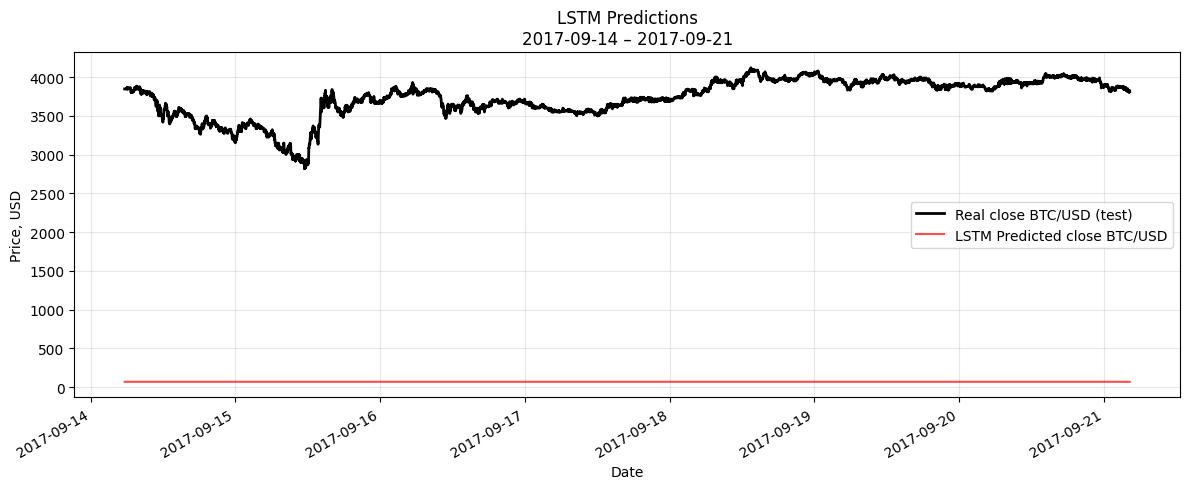

Тестовая выборка: 2017-09-14 05:39:00 – 2017-09-21 04:18:00
y_pred range: 68.76 - 68.78
y_real range: 2817.00 - 4119.50


In [15]:
slice_df = data.iloc[train_size:train_size + 10000].copy()
print("slice_df shape:", slice_df.shape)

features_num = ['timestamp', 'open', 'high', 'close', 'volume',
                'quote_asset_volume', 'number_of_trades',
                'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']

slice_X_num = slice_df[features_num].astype('float32').values

slice_X_scaled = scaler.transform(slice_X_num)

slice_X_lstm = slice_X_scaled.reshape((slice_X_scaled.shape[0],
                                       slice_X_scaled.shape[1],
                                       1)).astype('float32')

print(f"Model input shape: {model.input_shape}") 
print(f"slice_X_lstm shape: {slice_X_lstm.shape}")

y_pred = model.predict(slice_X_lstm, batch_size=256, verbose=0).flatten()

dates = pd.to_datetime(slice_df['timestamp'])
y_real = y_test.values  

start_date = dates.min()
end_date = dates.max()

plt.figure(figsize=(12, 5))
plt.plot(dates, y_real, label='Real close BTC/USD (test)', color='black', linewidth=2)
plt.plot(dates, y_pred, label='LSTM Predicted close BTC/USD', color='red', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price, USD')
plt.title(f'LSTM Predictions\n{start_date.date()} – {end_date.date()}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Тестовая выборка: {start_date} – {end_date}")
print(f"y_pred range: {y_pred.min():.2f} - {y_pred.max():.2f}")
print(f"y_real range: {y_real.min():.2f} - {y_real.max():.2f}")


In [24]:
import glob
import re
# Ищем ВСЕ файлы *_metrics_50.json
metrics_files = glob.glob("*_metrics_50.json")

models = {}

# Читаем метрики из каждого файла
for file in metrics_files:
    if os.path.exists(file):
        with open(file, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
            # Извлекаем номер модели ИЛИ ставим 1 для первой модели
            match = re.search(r'best_model_(\d+)', file)
            if match:
                model_num = int(match.group(1))
            else:
                model_num = 1  # Первая модель без номера
            
            models[model_num] = {
                'file': file,
                'val_rmse': data['val_root_mean_squared_error'],
                'val_mae': data['val_mae'],
                'val_mape': data['val_mape'],
                'val_r2': data['val_r2'],
                'val_loss':data['val_loss']
            }

sorted_models = sorted(models.items(), key=lambda x: x[1]['val_rmse'])

print("\n" + "="*70)
print("Рейтинг моделей по val_RMSE")
print("="*70)
print(f"{'#':<3} {'Модель':<8} {'Файл':<30} {'val_rmse':<12} {'val_r2':<10}")
print("-"*70)

for rank, (model_num, info) in enumerate(sorted_models, 1):
    print(f"{rank:<3} #{model_num:<7} {info['file']:<30} {info['val_rmse']:<12.3f} {info['val_r2']:<10.3f}")

print("\n" + "ЛУЧШАЯ МОДЕЛЬ")
best_model_num = sorted_models[0][0]
best_info = sorted_models[0][1]
print(f"Модель #{best_model_num}")
print(f"Файл: {best_info['file']}")
print(f"val_rmse: {best_info['val_rmse']:.3f}")
print(f"val_mae:  {best_info['val_mae']:.3f}")
print(f"val_mape: {best_info['val_mape']:.3f}")
print(f"val_r2:   {best_info['val_r2']:.3f}")
print(f"val_loss:   {best_info['val_loss']:.3f}")



Рейтинг моделей по val_RMSE
#   Модель   Файл                           val_rmse     val_r2    
----------------------------------------------------------------------
1   #2       best_model_2_metrics_50.json   29.015       0.986     
2   #4       best_model_4_metrics_50.json   47.431       0.963     
3   #1       best_model_metrics_50.json     57.446       0.945     
4   #3       best_model_3_metrics_50.json   71.345       0.916     
5   #5       best_model_5_metrics_50.json   3673.159     -222.587  

ЛУЧШАЯ МОДЕЛЬ
Модель #2
Файл: best_model_2_metrics_50.json
val_rmse: 29.015
val_mae:  25.926
val_mape: 0.700
val_r2:   0.986
val_loss:   25.238


In [16]:
print(data['timestamp'].min(), data['timestamp'].max())

1502942400000000000 1690895940000000000
